# Run artworks example

This notebook implements a quick inference on the labeled examples. Since the examples source code are now stored in a JSON file, and not into seperate files, we have this notebook to not interfeer with he code that will be used to run on the new source code files.

## Imports, configs and read data

In [1]:
import json
import yaml
from Model import LLM_Model
from Prompts import *
from collections import Counter
import matplotlib.pyplot as plt

def get_prompt_template(prompt_version):
    return globals()[prompt_version].template

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})

        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return dict(counter)


def count_all_labels(examples):
    return {
        "classification": count_labels(examples, "classification"),
        "predicted_classification": count_labels(examples, "predicted_classification"),
    }

def count_labels(examples, classification_key):
    counter = Counter()

    for ex in examples:
        classification = ex.get(classification_key, {})
        for dimension, labels in classification.items():
            for label in labels:
                counter[f"{dimension}_{label}"] += 1

    return counter


def plot_all_distributions(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    all_labels = sorted(set(true_counts) | set(pred_counts))
    x = range(len(all_labels))
    width = 0.4

    plt.figure(figsize=(12, 5))
    plt.bar([i - width/2 for i in x], [true_counts.get(label, 0) for label in all_labels], width=width, label="classification")
    plt.bar([i + width/2 for i in x], [pred_counts.get(label, 0) for label in all_labels], width=width, label="predicted_classification")

    plt.xticks(x, all_labels, rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("Classification vs Predicted Classification")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_distributions_by_dimension(examples):
    true_counts = count_labels(examples, "classification")
    pred_counts = count_labels(examples, "predicted_classification")

    for dimension in ["entities", "interaction", "outcome"]:
        labels = sorted([
            key.split("_", 1)[1]
            for key in set(true_counts) | set(pred_counts)
            if key.startswith(f"{dimension}_")
        ])

        x = range(len(labels))
        width = 0.4

        plt.figure(figsize=(8, 4)) 
        plt.bar([i - width/2 for i in x], [true_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="classification")
        plt.bar([i + width/2 for i in x], [pred_counts.get(f"{dimension}_{label}", 0) for label in labels], width=width, label="predicted_classification")

        plt.xticks(x, labels, rotation=45, ha="right")
        plt.ylabel("Count")
        plt.title(f"{dimension}: classification vs predicted")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [2]:
# Read configs
print("Configs...")
with open("../config.yml", "r") as f:
    configs = yaml.safe_load(f)

config_mode = configs["chosen_config"]['config_mode']
model = configs["chosen_config"]["model"]

Configs...


In [3]:
# Read examples
with open("../examples/artworks_corrected_classif.json") as f:
    examples = json.load(f)

# Print one examples
# examples[0]

In [4]:
llm_model = LLM_Model(
    model_name=configs[model]['model_name'],
    base_url=configs[model]['base_url'],
    system_prompt=configs[model]['system_prompt']
)

## Inference

In [5]:
prompt_version = "PROMPT_12"
prompt = get_prompt_template(prompt_version)

print("Using this prompt:\n", prompt)

for i, artwork in enumerate(examples):
    # Read src code
    art_src_code = artwork['metadata']['content']

    # Pass it to LLM
    predicted_labels = llm_model.get_labels(
        prompt_template=prompt, 
        art_src_code=art_src_code, 
        system_prompt=llm_model.system_prompt
    )
    if isinstance(predicted_labels.get("interaction"), str):
        predicted_labels["interaction"] = [predicted_labels["interaction"]]
    # print("Actual labels:", artwork['classification'])
    # print("Predicted labels:", predicted_labels)

    # Add prediction back to the json
    examples[i]["predicted_classification"] = predicted_labels
    

Using this prompt:
 You classify p5.js source code.

Return ONLY valid JSON in this format:
{"entities":[],"interaction":[],"outcome":[]}

Allowed tags:

entities:
- "processed_audio"
- "processed_image"
- "processed_text"
- "synthesized_sound"
- "synthesized_image"
- "synthesized_text"
- "randomness"

interaction:
- "yes"
- "no"

outcome:
- "visual"
- "auditory"
- "static"
- "time_based"

Rules:

1. entities

Use "processed_audio" if the code loads, captures, reads, or uses existing audio.
Examples: loadSound(), audio files, microphone, audio input.

Use "processed_image" if the code loads, captures, reads, or uses existing visual media.
Examples: loadImage(), loadAnimation(), image files, GIFs, video, webcam, createCapture(VIDEO).

Use "processed_text" if the code loads, reads, or processes existing text/data.
Examples: loadJSON(), loadStrings(), loadTable(), loadXML(), external text/data files, user-entered text that is processed.

Use "synthesized_sound" if the code generates or al

## Data Viz

In [6]:
results = count_all_labels(examples)

results["classification"]
results["predicted_classification"]

Counter({'outcome_visual': 74,
         'outcome_time_based': 71,
         'entities_synthesized_image': 66,
         'entities_randomness': 54,
         'interaction_no': 51,
         'interaction_yes': 23,
         'entities_processed_image': 14,
         'entities_processed_audio': 7,
         'entities_processed_text': 5,
         'entities_synthesized_sound': 3,
         'outcome_static': 3,
         'outcome_auditory': 3,
         'entities_synthesized_text': 2})

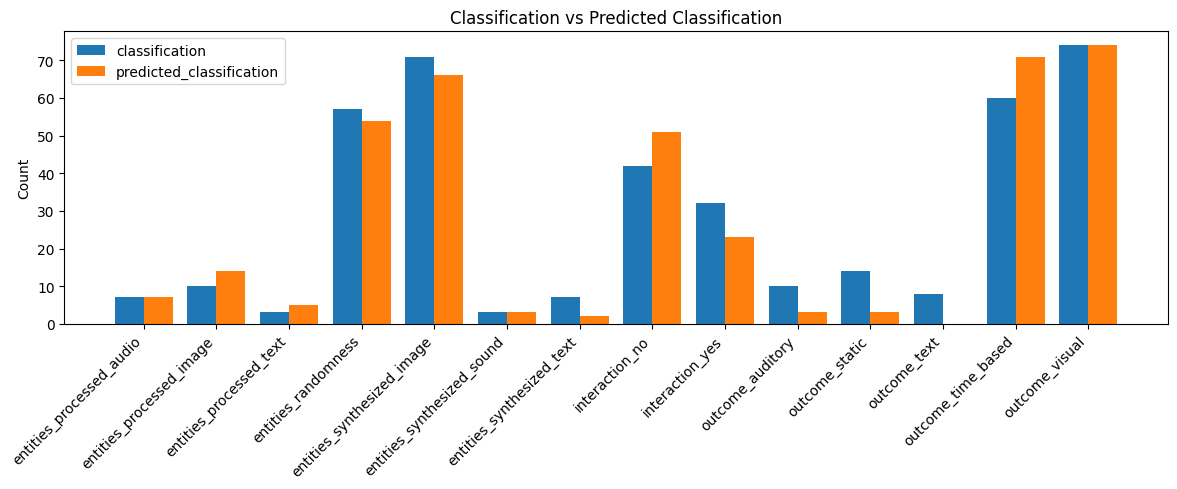

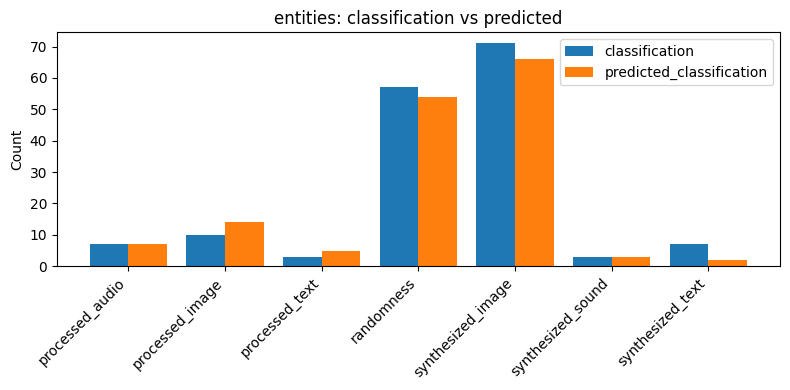

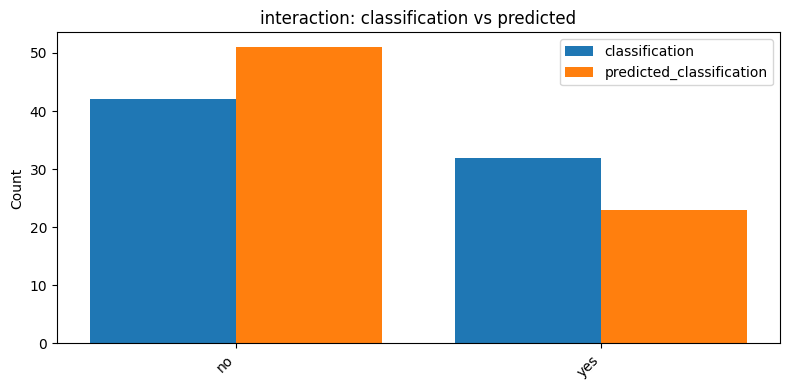

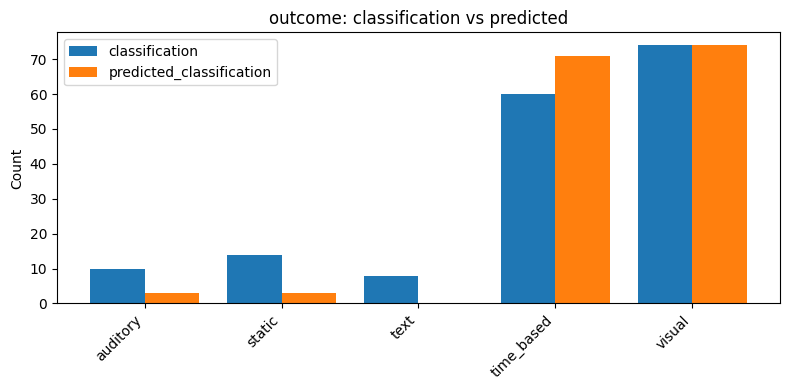

In [7]:
plot_all_distributions(examples)
plot_distributions_by_dimension(examples)